In [19]:
import random
from typing import Sequence

import matplotlib.pyplot as plt
import numpy
import pandas
from functools import lru_cache
from deap import algorithms
from deap import base, creator, tools
from scipy.stats import pointbiserialr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import roc_auc_score

# PREPARATION

In [20]:
# Define random seeds for reproducibility
SEED: int = 42
random.seed(SEED)
numpy.random.seed(SEED)

In [21]:
# Constants
#CSV_TRAIN_PATH: str = "diabetes/diabetes_preprocessed_train_data.csv"
#CSV_TEST_PATH: str = "diabetes/diabetes_preprocessed_test_data.csv"
#TARGET_COLUMN: str = "Outcome"

CSV_TRAIN_PATH: str = "readmit/readmit_130_hospitals_preprocessed_train_data.csv"
CSV_TEST_PATH: str = "readmit/readmit_130_hospitals_preprocessed_test_data.csv"
TARGET_COLUMN: str = "target_readmitted"

# Bigger population -> bigger search space
POP_SIZE: int = 200
# Bigger generation number -> bigger convergence
NGEN: int = 100
# Crossing probability
CXPB: float = 0.5
# Mutation probability
MUTPB: float = 0.2

# Use ROC-AUC instead of PR-AUC
USE_ROC_AUC: bool = True

In [22]:
# Load train set
df_train: pandas.DataFrame = pandas.read_csv(CSV_TRAIN_PATH)

# Split data into training and validation sets
X_search_pandas: pandas.DataFrame = df_train.drop(columns=[TARGET_COLUMN])
y_search_pandas: pandas.Series = df_train[TARGET_COLUMN]

X_search: numpy.ndarray = numpy.ascontiguousarray(X_search_pandas.to_numpy(), dtype=numpy.float32)
y_search: numpy.ndarray = numpy.ascontiguousarray(y_search_pandas.to_numpy(), dtype=numpy.float32)

feature_names: list[str] = list(X_search_pandas.columns)

cv: StratifiedKFold = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

In [23]:
# Load test set
df_test: pandas.DataFrame = pandas.read_csv(CSV_TEST_PATH)

y_test: pandas.Series = df_test[TARGET_COLUMN]
X_test: pandas.DataFrame = df_test.drop(columns=[TARGET_COLUMN])

In [24]:
# Calculate Point-biserial correlation coefficients (target value is binary and the input variables are continuous)
# Calculate the average correlation for each feature across all fold
correlation_between_target_and_features: list[pandas.Series] = []
for train_idx, val_idx in cv.split(X_search, y_search):
    X_fold_train: numpy.ndarray = X_search[train_idx]
    y_fold_train: numpy.ndarray = y_search[train_idx]

    corr_series: pandas.Series = pandas.Series(dtype=float)

    # Iterate through the number of features (columns)
    for col_idx in range(X_fold_train.shape[1]):
        feature_col: numpy.ndarray = X_fold_train[:, col_idx]

        # Check for unique values in the numpy column
        if len(numpy.unique(feature_col)) <= 2:
            corr: float = matthews_corrcoef(y_fold_train, feature_col)
        else:
            corr, _ = pointbiserialr(y_fold_train, feature_col)

        # Using the index as the key since numpy arrays don't have column names
        corr_series[f"column_{col_idx}"] = corr

    correlation_between_target_and_features.append(corr_series)

# MULTI OBJECTIVE

In [25]:
def coefficient_sign_score(coefficients: dict[str, float], corr_series: pandas.Series,
                           zero_tol: float = 1e-12) -> float:
    """
    Calculate the coefficient sign consistency score.

    Parameters:
        coefficients (dict[str, float]): Coefficients of the model.
        corr_series (pandas.Series): Pearson correlation coefficients.
        zero_tol (float): Tolerance for considering a value as zero.

    Returns:
        float: Coefficient sign consistency score.
    """
    penalties: float = 0.0
    total: int = len(coefficients)

    if total == 0:
        return 0.0

    for feature_name, coefficient in coefficients.items():
        correlation: float = corr_series[feature_name]

        if numpy.isnan(correlation):
            penalties += 1.0
            continue

        check: float = correlation * coefficient

        if numpy.isclose(check, 0.0, atol=zero_tol) or check < 0:
            penalties += 1.0

    return 1.0 - penalties / total

In [26]:
# Cache the results of evaluate_multi
def evaluate_multi(individual: Sequence[int]) -> tuple[float, float]:
    return _evaluate_multi_cached(tuple(individual))

@lru_cache(maxsize=None)
def _evaluate_multi_cached(individual: Sequence[int]) -> tuple[float, float]:
    if sum(individual) == 0:
        return 0.0, 0.0

    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    X_subset: numpy.ndarray = X_search[:, cols]

    auc_scores: list[float] = []
    sign_scores: list[float] = []

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_subset, y_search)):
        X_fold_train, X_fold_val = X_subset[train_idx], X_subset[val_idx]
        y_fold_train, y_fold_val = y_search[train_idx], y_search[val_idx]

        scaler: StandardScaler = StandardScaler()
        X_fold_train_scaled: numpy.ndarray = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled: numpy.ndarray = scaler.transform(X_fold_val)

        model: LogisticRegression = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=SEED)
        model.fit(X_fold_train_scaled, y_fold_train)

        probs: numpy.ndarray = model.predict_proba(X_fold_val_scaled)[:, 1]
        if USE_ROC_AUC:
            fold_auc: float = roc_auc_score(y_fold_val, probs)
        else:
            fold_auc: float = average_precision_score(y_fold_val, probs)
        auc_scores.append(fold_auc)

        coef_dict: dict[str, float] = {
            f"column_{original_idx}": model.coef_[0][j]
            for j, original_idx in enumerate(cols)
        }
        fold_corr_series: pandas.Series = correlation_between_target_and_features[fold_idx]
        fold_sign: float = coefficient_sign_score(coef_dict, fold_corr_series)
        sign_scores.append(fold_sign)

    return numpy.mean(auc_scores), numpy.mean(sign_scores)

In [27]:
if "FitnessMulti" not in creator.__dict__:
    creator.create("FitnessMulti", base.Fitness, weights=(1.0, 1.0))

if "Individual" not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.Individual,
    toolbox.attr_bool,
    n=X_search.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate", evaluate_multi)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(feature_names))
toolbox.register("select", tools.selNSGA2)

In [28]:
pop: list[creator.Individual] = toolbox.population(n=POP_SIZE)

# Initial evaluation
invalid: list[creator.Individual] = [ind for ind in pop if not ind.fitness.valid]
fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
for ind, fit in zip(invalid, fitnesses):
    ind.fitness.values = fit

# Crowding distance assignment
pop: list[creator.Individual] = toolbox.select(pop, len(pop))  # crowding assignment

# Pareto archive
hof: tools.ParetoFront = tools.ParetoFront()
hof.update(pop)

# Genetic algorithm
for gen in range(NGEN):
    # Binary tournament selection (NSGA-II)
    offspring: list[creator.Individual] = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Crossover
    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() <= CXPB:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values
            del ind2.fitness.values

    # Mutation
    for mutant in offspring:
        if random.random() <= MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Fitness evaluation
    invalid: list[creator.Individual] = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses: list[tuple[float, float]] = list(map(toolbox.evaluate, invalid))
    for ind, fit in zip(invalid, fitnesses):
        ind.fitness.values = fit

    # Combine parents + offspring
    combined: list[creator.Individual] = pop + offspring

    # NSGA-II survival selection
    pop: list[creator.Individual] = toolbox.select(pop + offspring, POP_SIZE)

    # Update global Pareto archive
    hof.update(pop)

    print(f"Generation {gen + 1} done | Pareto size: {len(hof)}")

Generation 1 done | Pareto size: 5
Generation 2 done | Pareto size: 7
Generation 3 done | Pareto size: 10
Generation 4 done | Pareto size: 9
Generation 5 done | Pareto size: 10
Generation 6 done | Pareto size: 12
Generation 7 done | Pareto size: 10
Generation 8 done | Pareto size: 13
Generation 9 done | Pareto size: 8
Generation 10 done | Pareto size: 5
Generation 11 done | Pareto size: 6
Generation 12 done | Pareto size: 6
Generation 13 done | Pareto size: 8
Generation 14 done | Pareto size: 11
Generation 15 done | Pareto size: 9
Generation 16 done | Pareto size: 10
Generation 17 done | Pareto size: 13
Generation 18 done | Pareto size: 8
Generation 19 done | Pareto size: 11
Generation 20 done | Pareto size: 13
Generation 21 done | Pareto size: 6
Generation 22 done | Pareto size: 9
Generation 23 done | Pareto size: 11
Generation 24 done | Pareto size: 9
Generation 25 done | Pareto size: 12
Generation 26 done | Pareto size: 6
Generation 27 done | Pareto size: 7
Generation 28 done | Pare

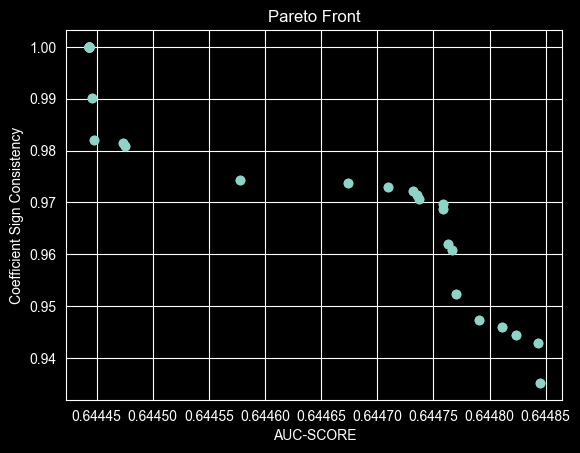

In [29]:
pareto: list[creator.Individual] = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

auc_values: list[float] = [ind.fitness.values[0] for ind in pareto]
sign_values: list[float] = [ind.fitness.values[1] for ind in pareto]

plt.scatter(auc_values, sign_values)
plt.xlabel("AUC-SCORE")
plt.ylabel("Coefficient Sign Consistency")
plt.title("Pareto Front")
plt.show()

In [30]:
# Convert Pareto front fitness values to numpy array
points: numpy.ndarray = numpy.array([ind.fitness.values for ind in pareto])

# Extreme points
max_auc_index: int = int(numpy.argmax(points[:, 0]))
max_sign_index: int = int(numpy.argmax(points[:, 1]))

max_auc_ind: creator.Individual = pareto[max_auc_index]
max_sign_ind: creator.Individual = pareto[max_sign_index]

# Knee-point calculation
p1: numpy.ndarray = points[max_auc_index]
p2: numpy.ndarray = points[max_sign_index]

if numpy.allclose(p1, p2):
    knee_index: int = 0
else:
    line_vector: numpy.ndarray = p2 - p1
    line_vector = line_vector / numpy.linalg.norm(line_vector)

    distances: list[float] = []

    for p in points:
        vector: numpy.ndarray = p - p1
        projection: numpy.ndarray = numpy.dot(vector, line_vector) * line_vector
        orthogonal: numpy.ndarray = vector - projection
        distances.append(float(numpy.linalg.norm(orthogonal)))

    knee_index: int = int(numpy.argmax(distances))

knee_ind: creator.Individual = pareto[knee_index]

# Helper function to extract info
def extract_info(individual) -> tuple[float, float, int, numpy.ndarray]:
    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    auc: float = individual.fitness.values[0]
    sign_consistency: float = individual.fitness.values[1]
    n_features: int = len(cols)
    return auc, sign_consistency, n_features, cols

auc1, sign1, nf1, cols1 = extract_info(max_auc_ind)
auc2, sign2, nf2, cols2 = extract_info(max_sign_ind)
auc3, sign3, nf3, cols3 = extract_info(knee_ind)

print("\n=== Pareto Front Model Comparison On Validation Set ===\n")

print("1) Maximum AUC model")
print(f"AUC on validation set: {auc1:.4f}")
print(f"Sign consistency on validation set: {sign1:.4f}")
print(f"Number of features: {nf1}")

print("\n2) Maximum Sign Consistency model")
print(f"AUC on validation set: {auc2:.4f}")
print(f"Sign consistency on validation set: {sign2:.4f}")
print(f"Number of features: {nf2}")

print("\n3) Knee-point model (balanced solution)")
print(f"AUC on validation set: {auc3:.4f}")
print(f"Sign consistency on validation set: {sign3:.4f}")
print(f"Number of features: {nf3}")


=== Pareto Front Model Comparison On Validation Set ===

1) Maximum AUC model
AUC on validation set: 0.6448
Sign consistency on validation set: 0.9352
Number of features: 36

2) Maximum Sign Consistency model
AUC on validation set: 0.6444
Sign consistency on validation set: 1.0000
Number of features: 33

3) Knee-point model (balanced solution)
AUC on validation set: 0.6448
Sign consistency on validation set: 0.9697
Number of features: 33


In [31]:
# Calculate the final results on the test set
def evaluate_on_test(cols: numpy.ndarray) -> tuple[float, float]:
    X_search_reduced: numpy.ndarray = X_search[:, cols]
    X_test_reduced: numpy.ndarray = X_test.to_numpy()[:, cols]

    scaler: StandardScaler = StandardScaler()
    X_search_reduced_scaled: numpy.ndarray = scaler.fit_transform(X_search_reduced)
    X_test_reduced_scaled: numpy.ndarray = scaler.transform(X_test_reduced)

    model: LogisticRegression = LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        max_iter=1000,
        random_state=SEED)
    model.fit(X_search_reduced_scaled, y_search)

    test_probs: numpy.ndarray = model.predict_proba(X_test_reduced_scaled)[:, 1]
    roc_auc: float = roc_auc_score(y_test, test_probs)
    pr_auc: float = average_precision_score(y_test, test_probs)

    return roc_auc, pr_auc

roc_auc1_t, pr_auc1_t = evaluate_on_test(cols1)
roc_auc2_t, pr_auc2_t = evaluate_on_test(cols2)
roc_auc3_t, pr_auc3_t = evaluate_on_test(cols3)

print("\n=== Test Set Model Comparison ===\n")

print("1) Maximum AUC model")
print(f"ROC-AUC on test set: {roc_auc1_t:.4f}")
print(f"PR-AUC on test set: {pr_auc1_t:.4f}")
print(f"Number of features: {nf1}")

print("\n2) Maximum Sign Consistency model")
print(f"ROC-AUC on test set: {roc_auc2_t:.4f}")
print(f"PR-AUC on test set: {pr_auc2_t:.4f}")
print(f"Number of features: {nf2}")

print("\n3) Knee-point model (balanced solution)")
print(f"ROC-AUC on test set: {roc_auc3_t:.4f}")
print(f"PR-AUC on test set: {pr_auc3_t:.4f}")
print(f"Number of features: {nf3}")


=== Test Set Model Comparison ===

1) Maximum AUC model
ROC-AUC on test set: 0.6422
PR-AUC on test set: 0.1984
Number of features: 36

2) Maximum Sign Consistency model
ROC-AUC on test set: 0.6410
PR-AUC on test set: 0.1982
Number of features: 33

3) Knee-point model (balanced solution)
ROC-AUC on test set: 0.6421
PR-AUC on test set: 0.1985
Number of features: 33


# SINGLE OBJECTIVE

In [32]:
# Reset random seeds for reproducibility
random.seed(SEED)
numpy.random.seed(SEED)

In [33]:
# Cache the results of evaluate_multi
def evaluate_single(individual: Sequence[int]) -> tuple[float]:
    return _evaluate_single_cached(tuple(individual))

@lru_cache(maxsize=None)
def _evaluate_single_cached(individual: Sequence[int]) -> tuple[float]:
    if sum(individual) == 0:
        return 0.0, 0.0

    cols: numpy.ndarray = numpy.where(numpy.array(individual) == 1)[0]
    X_subset: numpy.ndarray = X_search[:, cols]

    auc_scores: list[float] = []

    for train_idx, val_idx in cv.split(X_subset, y_search):
        X_fold_train, X_fold_val = X_subset[train_idx], X_subset[val_idx]
        y_fold_train, y_fold_val = y_search[train_idx], y_search[val_idx]

        scaler: StandardScaler = StandardScaler()
        X_fold_train_scaled: numpy.ndarray = scaler.fit_transform(X_fold_train)
        X_fold_val_scaled: numpy.ndarray = scaler.transform(X_fold_val)

        model: LogisticRegression = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=1000,
            random_state=SEED)
        model.fit(X_fold_train_scaled, y_fold_train)

        probs: numpy.ndarray = model.predict_proba(X_fold_val_scaled)[:, 1]

        if USE_ROC_AUC:
            fold_auc = roc_auc_score(y_fold_val, probs)
        else:
            fold_auc = average_precision_score(y_fold_val, probs)
        auc_scores.append(fold_auc)

    return (numpy.mean(auc_scores),)

In [34]:
if "FitnessSingle" not in creator.__dict__:
    creator.create("FitnessSingle", base.Fitness, weights=(1.0,))

if "IndividualSingle" not in creator.__dict__:
    creator.create("IndividualSingle", list, fitness=creator.FitnessSingle)

In [35]:
toolbox: base.Toolbox = base.Toolbox()

toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register(
    "individual",
    tools.initRepeat,
    creator.IndividualSingle,
    toolbox.attr_bool,
    n=X_search.shape[1],
)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_single)
toolbox.register("mate", tools.cxUniform, indpb=0.5)
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0 / len(feature_names))
toolbox.register("select", tools.selTournament, tournsize=3)

pop: list[creator.IndividualSingle] = toolbox.population(n=POP_SIZE)
hof: tools.HallOfFame = tools.HallOfFame(1)

stats: tools.Statistics = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max", numpy.max)

pop, logbook = algorithms.eaSimple(
    pop,
    toolbox,
    cxpb=0.5,
    mutpb=0.2,
    ngen=NGEN,
    stats=stats,
    halloffame=hof,
    verbose=True
)

best_individual: creator.IndividualSingle = hof[0]
best_cols: list[int] = [i for i, bit in enumerate(best_individual) if bit == 1]

selected_feature_names: list[str] = [feature_names[i] for i in best_cols]
selected_feature_names.sort()
print("Selected features:", selected_feature_names)

gen	nevals	max     
0  	200   	0.638196
1  	122   	0.63979 
2  	116   	0.640559
3  	132   	0.641051
4  	123   	0.641456
5  	134   	0.642106
6  	121   	0.642106
7  	133   	0.642196
8  	120   	0.642484
9  	126   	0.642629
10 	116   	0.642947
11 	114   	0.64309 
12 	122   	0.643382
13 	123   	0.643437
14 	128   	0.64355 
15 	120   	0.64374 
16 	118   	0.64399 
17 	115   	0.644015
18 	103   	0.644051
19 	125   	0.644404
20 	115   	0.644404
21 	121   	0.644525
22 	126   	0.644557
23 	110   	0.644604
24 	109   	0.644631
25 	113   	0.644691
26 	121   	0.644691
27 	114   	0.64474 
28 	119   	0.64474 
29 	124   	0.644739
30 	119   	0.644788
31 	124   	0.644788
32 	129   	0.644803
33 	115   	0.644802
34 	114   	0.644806
35 	123   	0.644813
36 	117   	0.644821
37 	121   	0.644821
38 	128   	0.64483 
39 	112   	0.644831
40 	116   	0.644831
41 	121   	0.644831
42 	120   	0.644831
43 	115   	0.644831
44 	119   	0.644834
45 	124   	0.644836
46 	133   	0.644836
47 	115   	0.644836
48 	126   	0.644836


In [36]:
# Calculate the final results on the test set
X_search_reduced: numpy.ndarray = X_search[:, best_cols]
X_test_reduced: numpy.ndarray = X_test.to_numpy()[:, best_cols]

scaler: StandardScaler = StandardScaler()
X_search_reduced_scaled: numpy.ndarray = scaler.fit_transform(X_search_reduced)
X_test_reduced_scaled: numpy.ndarray = scaler.transform(X_test_reduced)

model: LogisticRegression = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED)
model.fit(X_search_reduced_scaled, y_search)

test_probs: numpy.ndarray = model.predict_proba(X_test_reduced_scaled)[:, 1]
test_roc_auc: float = roc_auc_score(y_test, test_probs)
test_pr_auc: float = average_precision_score(y_test, test_probs)

print("\n=== Test Set Model Comparison ===\n")

print(f"ROC-AUC on test set: {test_roc_auc:.4f}")
print(f"PR-AUC on test set: {test_pr_auc:.4f}")
print(f"Number of features: {len(best_cols)}")


=== Test Set Model Comparison ===

ROC-AUC on test set: 0.6421
PR-AUC on test set: 0.1984
Number of features: 39
